In [1]:
from google.colab import files

uploaded = files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("dirty_cafe_sales.csv")

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
print(df.shape)

df.info()

df.describe(include='all')

(10000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [5]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [6]:
df.replace("UNKNOWN", np.nan, inplace=True)

In [7]:
df.isnull().sum()

,0
Transaction ID,0
Item,677
Quantity,309
Price Per Unit,343
Total Spent,338
Payment Method,2872
Location,3603
Transaction Date,318


In [8]:
df["Item"].fillna(df["Item"].mode()[0], inplace=True)

/tmp/ipykernel_8941/1307722615.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Item"].fillna(df["Item"].mode()[0], inplace=True)


In [9]:
df["Payment Method"].fillna(
    df["Payment Method"].mode()[0],
    inplace=True
)

/tmp/ipykernel_8941/375118360.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Payment Method"].fillna(


In [10]:
df["Location"].fillna(
    df["Location"].mode()[0],
    inplace=True
)

/tmp/ipykernel_8941/1169903526.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Location"].fillna(


In [13]:
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Price Per Unit"] = pd.to_numeric(
    df["Price Per Unit"],
    errors="coerce"
)

df["Total Spent"] = pd.to_numeric(
    df["Total Spent"],
    errors="coerce"
)

In [14]:
df["Quantity"].fillna(
    df["Quantity"].median(),
    inplace=True
)

df["Price Per Unit"].fillna(
    df["Price Per Unit"].median(),
    inplace=True
)

df["Total Spent"].fillna(
    df["Total Spent"].median(),
    inplace=True
)

/tmp/ipykernel_8941/3222857862.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Quantity"].fillna(
/tmp/ipykernel_8941/3222857862.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: val

In [15]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

In [16]:
df["Transaction Date"].fillna(
    df["Transaction Date"].mode()[0],
    inplace=True
)

/tmp/ipykernel_8941/1486179819.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Transaction Date"].fillna(


In [18]:
df.to_csv(
    "cleaned_cafe_sales.csv",
    index=False
)

In [19]:
files.download(
    "cleaned_cafe_sales.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
total_revenue = df["Total Spent"].sum()

print(total_revenue)

88779.5


In [21]:
total_transactions = len(df)

print(total_transactions)

10000


In [22]:
avg_order = df["Total Spent"].mean()

print(avg_order)

8.87795


In [23]:
total_quantity = df["Quantity"].sum()

print(total_quantity)

30271.0


In [24]:
popular_item = df["Item"].mode()[0]

print(popular_item)

Juice


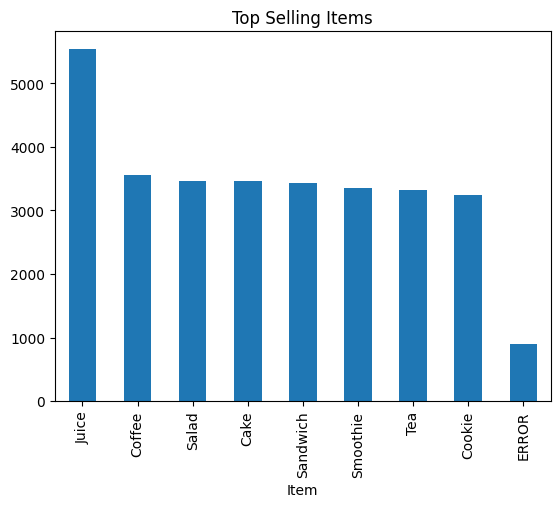

In [25]:
top_items = df.groupby(
    "Item"
)["Quantity"].sum()

top_items.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Top Selling Items")
plt.show()

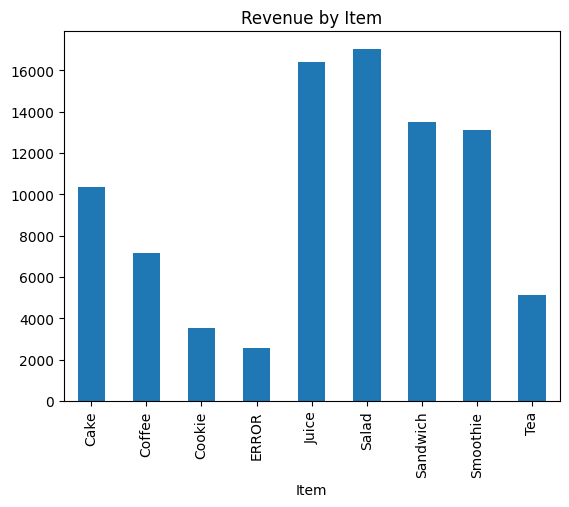

In [26]:
revenue = df.groupby(
    "Item"
)["Total Spent"].sum()

revenue.plot(kind="bar")

plt.title("Revenue by Item")

plt.show()

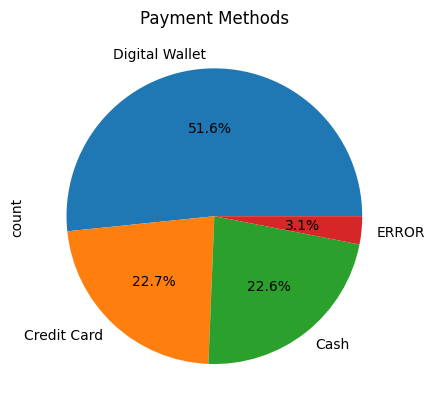

In [27]:
payment = df["Payment Method"].value_counts()

payment.plot(kind="pie",
             autopct="%1.1f%%")

plt.title("Payment Methods")

plt.show()

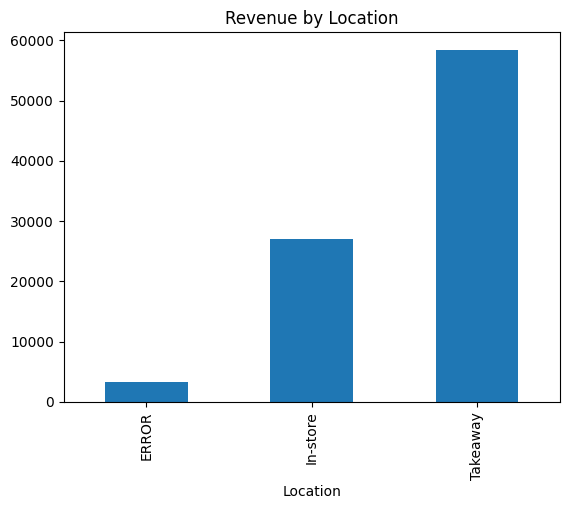

In [28]:
location = df.groupby(
    "Location"
)["Total Spent"].sum()

location.plot(kind="bar")

plt.title("Revenue by Location")

plt.show()

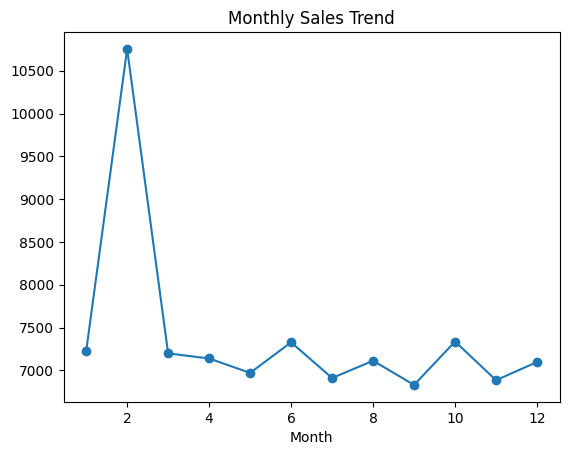

In [29]:
df["Month"] = df[
    "Transaction Date"
].dt.month

monthly = df.groupby(
    "Month"
)["Total Spent"].sum()

monthly.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.show()